# opensidewalks-nyc build walkthrough

This notebook is the audit trail for the OpenSidewalks v0.3 pedestrian graph of New York City. It reads the reports and artifacts left behind by `python -m pipeline build` (plus the post-build endpoint snap) and re-runs the official conformance check. Nothing here mutates the build; every cell is read-only against `data/` and `output/`.

Build artifacts covered:

| File | Contents |
|---|---|
| `output/nyc-osw.geojson` | Canonical OSW v0.3 FeatureCollection (nodes + edges) |
| `output/nyc-osw-osw-split.zip` | Split nodes/edges ZIP, the input `python-osw-validation` expects |
| `output/nyc.graphml` | Attributed graph for NetworkX / Gephi / igraph |
| `output/nyc-routing.json` | Flat nodes-dict + edges-list export for routing engines |

In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import geopandas as gpd
import numpy as np
import pandas as pd
import yaml

REPO   = Path.cwd().resolve()
if REPO.name == "notebooks":
    REPO = REPO.parent
RAW    = REPO / "data" / "raw"
CLEAN  = REPO / "data" / "clean"
STAGED = REPO / "data" / "staged"
OUT    = REPO / "output"

with open(REPO / "config" / "sources.yaml") as f:
    SOURCES = yaml.safe_load(f)["sources"]
with open(REPO / "config" / "build.yaml") as f:
    BUILD = yaml.safe_load(f)

## Inputs

Six sources. Stage 1 (`pipeline/stages/acquire.py`) writes a SHA-256 of every download into `data/raw/manifest.json`, so a rebuild against the same upstream snapshots yields identical hashes.

In [2]:
INPUTS = {
    "osm_walk": {
        "name":   "OpenStreetMap pedestrian-tagged ways (NYC)",
        "format": "OSMnx graph -> GeoJSON LineStrings",
        "license": "ODbL-1.0",
    },
    "nyc_planimetric_sidewalks": {
        "name":   "NYC Planimetric Database, sidewalk polygons (OTI)",
        "format": "Socrata GeoJSON Polygon",
        "license": "Public Domain (NYC Open Data)",
    },
    "nyc_dot_ramps": {
        "name":   "NYC DOT Pedestrian Ramp Locations (curb ramps)",
        "format": "Socrata GeoJSON Point",
        "license": "Public Domain (NYC Open Data)",
    },
    "nyc_boroughs": {
        "name":   "NYC Borough Boundaries (OSMnx geocode fallback)",
        "format": "GeoJSON MultiPolygon",
        "license": "Public Domain (NYC Open Data) / ODbL-1.0 (fallback)",
    },
    "dem_nyc": {
        "name":   "NYC 2017 1ft LiDAR bare-earth DTM (NYS GIS ImageServer)",
        "format": "GeoTIFF, one tile per borough",
        "license": "Public Domain (NY State)",
    },
    "mta_ada_stations": {
        "name":   "MTA subway stations with ADA flag",
        "format": "Socrata GeoJSON Point / GTFS fallback",
        "license": "Public Domain (MTA)",
    },
}

with open(RAW / "manifest.json") as f:
    fetched = json.load(f)

rows = []
for sid, meta in INPUTS.items():
    fm = fetched.get(sid, {})
    rows.append({
        "source":      sid,
        "description": meta["name"],
        "license":     meta["license"],
        "fetched_on":  fm.get("retrieved_at", "")[:10],
        "row_count":   fm.get("row_count", 0),
        "sha256_8":    (fm.get("content_hash") or "")[:8],
    })
pd.DataFrame(rows)

,source,description,license,fetched_on,row_count,sha256_8
0,osm_walk,OpenStreetMap pedestrian-tagged ways (NYC),ODbL-1.0,2026-07-03,2612511,ef827635
1,nyc_planimetric_sidewalks,"NYC Planimetric Database, sidewalk polygons (OTI)",Public Domain (NYC Open Data),2026-07-03,50865,585e6420
2,nyc_dot_ramps,NYC DOT Pedestrian Ramp Locations (curb ramps),Public Domain (NYC Open Data),2026-07-03,217679,5c4a4237
3,nyc_boroughs,NYC Borough Boundaries (OSMnx geocode fallback),Public Domain (NYC Open Data) / ODbL-1.0 (fall...,2026-07-03,5,2efea8e0
4,dem_nyc,NYC 2017 1ft LiDAR bare-earth DTM (NYS GIS Ima...,Public Domain (NY State),,0,
5,mta_ada_stations,MTA subway stations with ADA flag,Public Domain (MTA),2026-07-03,1488,561ea5cc


## Load

Confirm what Stage 1 wrote to `data/raw/`, with CRS and feature counts. The OSM extract is loaded lazily by Stage 2, so only its on-disk size is reported here.

In [3]:
boroughs    = gpd.read_file(RAW / "nyc_boroughs"              / "boroughs.geojson")
ramps       = gpd.read_file(RAW / "nyc_dot_ramps"             / "nyc_dot_ramps.geojson")
planimetric = gpd.read_file(RAW / "nyc_planimetric_sidewalks" / "nyc_planimetric_sidewalks.geojson")
ada         = gpd.read_file(RAW / "mta_ada_stations"          / "mta_ada_stations.geojson")

for label, gdf in [
    ("boroughs",    boroughs),
    ("curb ramps",  ramps),
    ("planimetric sidewalks", planimetric),
    ("MTA stations", ada),
]:
    print(f"  {label:24s}  {len(gdf):>9,} features   CRS {gdf.crs}")

osm_path = RAW / "osm_walk" / "osm_edges.geojson"
print(f"  {'osm_walk (on disk)':24s}  {osm_path.stat().st_size / 1e9:>5.2f} GB   (loaded lazily by stage 2)")

  boroughs                          5 features   CRS EPSG:4326
  curb ramps                  217,679 features   CRS EPSG:4326
  planimetric sidewalks        50,865 features   CRS EPSG:4326
  MTA stations                  1,488 features   CRS EPSG:4326
  osm_walk (on disk)         1.82 GB   (loaded lazily by stage 2)


## Reproject

Metric operations (snap tolerances, polygon centerlines, edge length) run in EPSG:32618 (UTM 18N, metres), which covers the whole city in one zone. Published artifacts are EPSG:4326.

In [4]:
boroughs_m = boroughs.to_crs("EPSG:32618")
boroughs_m = boroughs_m.assign(area_km2=boroughs_m.geometry.area / 1e6)
boroughs_m[["boro_name", "area_km2"]].sort_values("area_km2", ascending=False).reset_index(drop=True)

,boro_name,area_km2
0,Queens,465.065448
1,Staten Island,265.404884
2,Brooklyn,252.128282
3,Bronx County,148.868728
4,Manhattan,87.274241


## Clean

Stage 2 (`pipeline/stages/clean.py`) runs `make_valid` on every geometry and drops slivers under 1 m². The cleaning report is regenerated on every build.

In [5]:
print((CLEAN / "cleaning_report.md").read_text())

# Cleaning Report

Generated: 2026-07-03T15:02:36.150088+00:00

## Summary

| Source | Raw features | Dropped (geom) | Repaired (geom) | Clean features |
|--------|-------------|----------------|-----------------|----------------|
| nyc_boroughs | 5 | 0 | 0 | 5 |
| osm_walk | 2612511 | 0 | 0 | 2612511 |
| nyc_dot_ramps | 217679 | 0 | 0 | 217679 |
| nyc_planimetric_sidewalks | 50865 | 0 | 32 | 50865 |
| mta_ada_stations | 1488 | 0 | 0 | 1488 |

## Notes by Source

### nyc_boroughs
- No issues

### osm_walk
- No issues

### nyc_dot_ramps
- No issues

### nyc_planimetric_sidewalks
- Repaired 32 invalid geometries with make_valid()
- Dropped 2 slivers with area < 1 m²

### mta_ada_stations
- No issues



## Schema-map: derive OSW features

Stage 3 (`pipeline/stages/schema_map.py`) splits OSM walking edges into the four OSW edge classes (`Sidewalk`, `Crossing`, `Footway`, `Street`) from `highway`/`footway` tags, assigns sidewalk widths from the planimetric polygons, and derives gap-fill sidewalk centerlines (minimum-rotated-rectangle axis) from planimetric polygons not already covered by an OSM edge. Curb ramps become OSW curb Point nodes (`barrier=kerb`, `kerb=lowered`) carrying the DOT survey measurements as `ext:*` fields.

In [6]:
from pyogrio import read_info

staged_layers = {
    "sidewalks":  STAGED / "sidewalks.geojson",
    "crossings":  STAGED / "crossings.geojson",
    "footways":   STAGED / "footways.geojson",
    "streets":    STAGED / "streets.geojson",
    "curb_nodes": STAGED / "curb_nodes.geojson",
}

for name, path in staged_layers.items():
    info = read_info(path)
    print(f"  {name:12s}  {info['features']:>9,}  ({path.stat().st_size/1e6:>6.1f} MB)")

  sidewalks       935,981  ( 476.0 MB)


  crossings       435,272  ( 233.8 MB)


  footways        524,557  ( 255.4 MB)


  streets         682,423  ( 336.5 MB)


  curb_nodes      217,679  ( 126.7 MB)


## Assemble: topology and incline

Stage 4 snaps curb-ramp points to the nearest pedestrian edge endpoint (5 m), unifies near-coincident endpoints across sources (2 m, dropping edges that collapse to zero length in the process), injects nodes for any dangling endpoint, and samples the LiDAR DTM at node coordinates to compute per-edge `incline`. The post-build `scripts/snap_endpoints.py` then moves every edge's terminal vertices onto its referenced node coordinates, which the 0.4.x validator checks exactly.

In [7]:
print((STAGED / "topology_report.md").read_text())

# Topology Report

Generated: 2026-07-03T18:04:19.823623+00:00

## Graph Statistics

- Nodes in graph: 849,417
- Edges in graph: 949,411
- Connected components: 11,807
- Nodes in largest component: 515,336 (60.7%)
- Components ≥ 3 nodes: 3386
- Isolated/tiny components (< 3 nodes): 8421

## Component Size Distribution

| Rank | Component size |
|------|---------------|
| 1 | 515,336 |
| 2 | 132,012 |
| 3 | 72,105 |
| 4 | 16,187 |
| 5 | 11,743 |
| 6 | 5,406 |
| 7 | 4,225 |
| 8 | 1,293 |
| 9 | 1,252 |
| 10 | 1,235 |
| 11 | 1,212 |
| 12 | 1,134 |
| 13 | 1,050 |
| 14 | 965 |
| 15 | 739 |
| 16 | 725 |
| 17 | 715 |
| 18 | 677 |
| 19 | 655 |
| 20 | 550 |
| … | (11787 more) |


The graph is not one connected component and never will be: Staten Island is separated by water, and Rikers, Hart Island, and unmapped park interiors fragment the rest. The largest component holds about 61% of pedestrian-graph nodes and spans the four mainland boroughs. Routing consumers should snap query points to the giant component.

## Conformance

Two layers of checking. Stage 5 is the pipeline's internal pre-check (structural integrity over all features, JSON Schema over a sample). The release gate is the official `python-osw-validation` package run against the split ZIP; the next cell runs it live.

In [8]:
print((OUT / "validation_report.md").read_text())

# OSW Validation Report

Generated: 2026-07-03T18:12:55.208617+00:00

## Summary

- **Schema version targeted:** OpenSidewalks v0.3
- **Validator:** jsonschema (Draft7Validator) + structural integrity checks (JSON Schema validation on 2,000-feature sample; structural checks on all features)
- **Total features:** 3,374,261
- **Features passing all checks:** 3,374,261 (100.0%)
- **Features with at least one failure:** 0

## Results by Check Category

| Check | Failures |
|-------|---------|
| unique_id | ✅ pass |
| edge_geometry_type | ✅ pass |
| edge_node_reference | ✅ pass |
| curb_node_geometry | ✅ pass |
| wgs84_bounds | ✅ pass |
| json_schema | ✅ pass |

## Structural Conformance

All structural checks passed.

## JSON Schema Conformance

All JSON Schema checks passed (or schema not available).

## Known Limitations

- Incline requires the LiDAR DEM tiles and the optional rasterio dependency; absent either, edges carry no incline
- No accessibility condition ratings (requires field 

In [9]:
from python_osw_validation import OSWValidation

result = OSWValidation(str(OUT / "nyc-osw-osw-split.zip")).validate()
errors = result.errors or []
print(f"python-osw-validation: is_valid={result.is_valid}, errors={len(errors)}")
assert result.is_valid and not errors, errors[:5]

python-osw-validation: is_valid=True, errors=0


## Curb ramps carry the DOT survey

Spot-check at 5th Ave & W 42nd St: the nearest curb nodes should carry kerb, tactile paving, cross streets, and measured slopes from the DOT ramp survey.

In [10]:
from shapely.geometry import Point

TARGET = Point(-73.9822, 40.7536)   # 5th Ave & W 42nd St (NYPL Schwarzman Building)
target_proj = gpd.GeoSeries([TARGET], crs="EPSG:4326").to_crs("EPSG:32618").iloc[0]

curb_cols = ["_id", "kerb", "tactile_paving", "ext:street_1", "ext:street_2",
             "ext:running_slope_pct", "ext:cross_slope_pct"]
curbs = gpd.read_file(STAGED / "curb_nodes.geojson", columns=curb_cols).to_crs("EPSG:32618")

curbs = curbs.assign(d_m=curbs.distance(target_proj))
show = [c for c in ("d_m", "kerb", "tactile_paving", "ext:street_1", "ext:street_2",
                    "ext:running_slope_pct", "ext:cross_slope_pct") if c in curbs.columns]
print("6 nearest curb nodes to 5th Ave & W 42nd St:\n")
print(curbs.nsmallest(6, "d_m")[show].to_string(index=False))

6 nearest curb nodes to 5th Ave & W 42nd St:

       d_m    kerb tactile_paving   ext:street_1   ext:street_2  ext:running_slope_pct  ext:cross_slope_pct
 53.576346 lowered            yes WEST 42 STREET            NaN                    8.5                  1.8
 69.272030 lowered            yes WEST 42 STREET            NaN                   10.1                  0.5
 96.981752 lowered            yes WEST 42 STREET       5 AVENUE                   16.2                 -3.3
 98.914678 lowered            yes WEST 42 STREET       5 AVENUE                   10.2                 -1.9
100.317111 lowered            yes       5 AVENUE EAST 41 STREET                    8.9                 -1.1
105.074426 lowered            yes WEST 42 STREET       5 AVENUE                    4.1                  0.5


## Transit accessibility sidecar

MTA station points are not part of the graph topology. They are staged separately so a router can answer "is the closest station ADA-accessible". The flag is the static NYC Open Data value at fetch time; live elevator status belongs in the consuming application.

In [11]:
stations = gpd.read_file(STAGED / "mta_ada_stations.geojson")
ada_col = next((c for c in ("ada", "ada_accessible") if c in stations.columns), None)
if ada_col is not None:
    counts = stations[ada_col].astype(str).str.lower().value_counts()
    print("MTA station ADA flag distribution:")
    for k, v in counts.items():
        print(f"  {k:10s}  {v:>4,}")
print(f"\nTotal station points: {len(stations):,}")

MTA station ADA flag distribution:
  1           1,488

Total station points: 1,488


## Artifacts

SHA-256 fingerprints of the shipped files. The GraphML loads directly into NetworkX and Gephi; the routing JSON is a flat nodes-dict + edges-list for building a routing graph without an XML parse.

In [12]:
def sha256(path, chunk=1 << 20):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for block in iter(lambda: fh.read(chunk), b""):
            h.update(block)
    return h.hexdigest()

for name in ("nyc-osw.geojson", "nyc-osw-osw-split.zip", "nyc.graphml", "nyc-routing.json"):
    p = OUT / name
    print(f"  {name:24s} {p.stat().st_size/1e6:>8,.1f} MB  sha256 {sha256(p)[:16]}…")

  nyc-osw.geojson           1,276.4 MB  sha256 00860ab28ac263db…
  nyc-osw-osw-split.zip       124.4 MB  sha256 0681896f8acdcc39…


  nyc.graphml               1,561.3 MB  sha256 88a073099dbae9d1…


  nyc-routing.json          1,117.7 MB  sha256 92912f34887cc669…


## What the graph looks like

Every edge in the canonical artifact, drawn as its endpoint chord and colored by OSW class. Crossings trace the intersection grid; steps cluster on park stairs and elevated subway approaches.

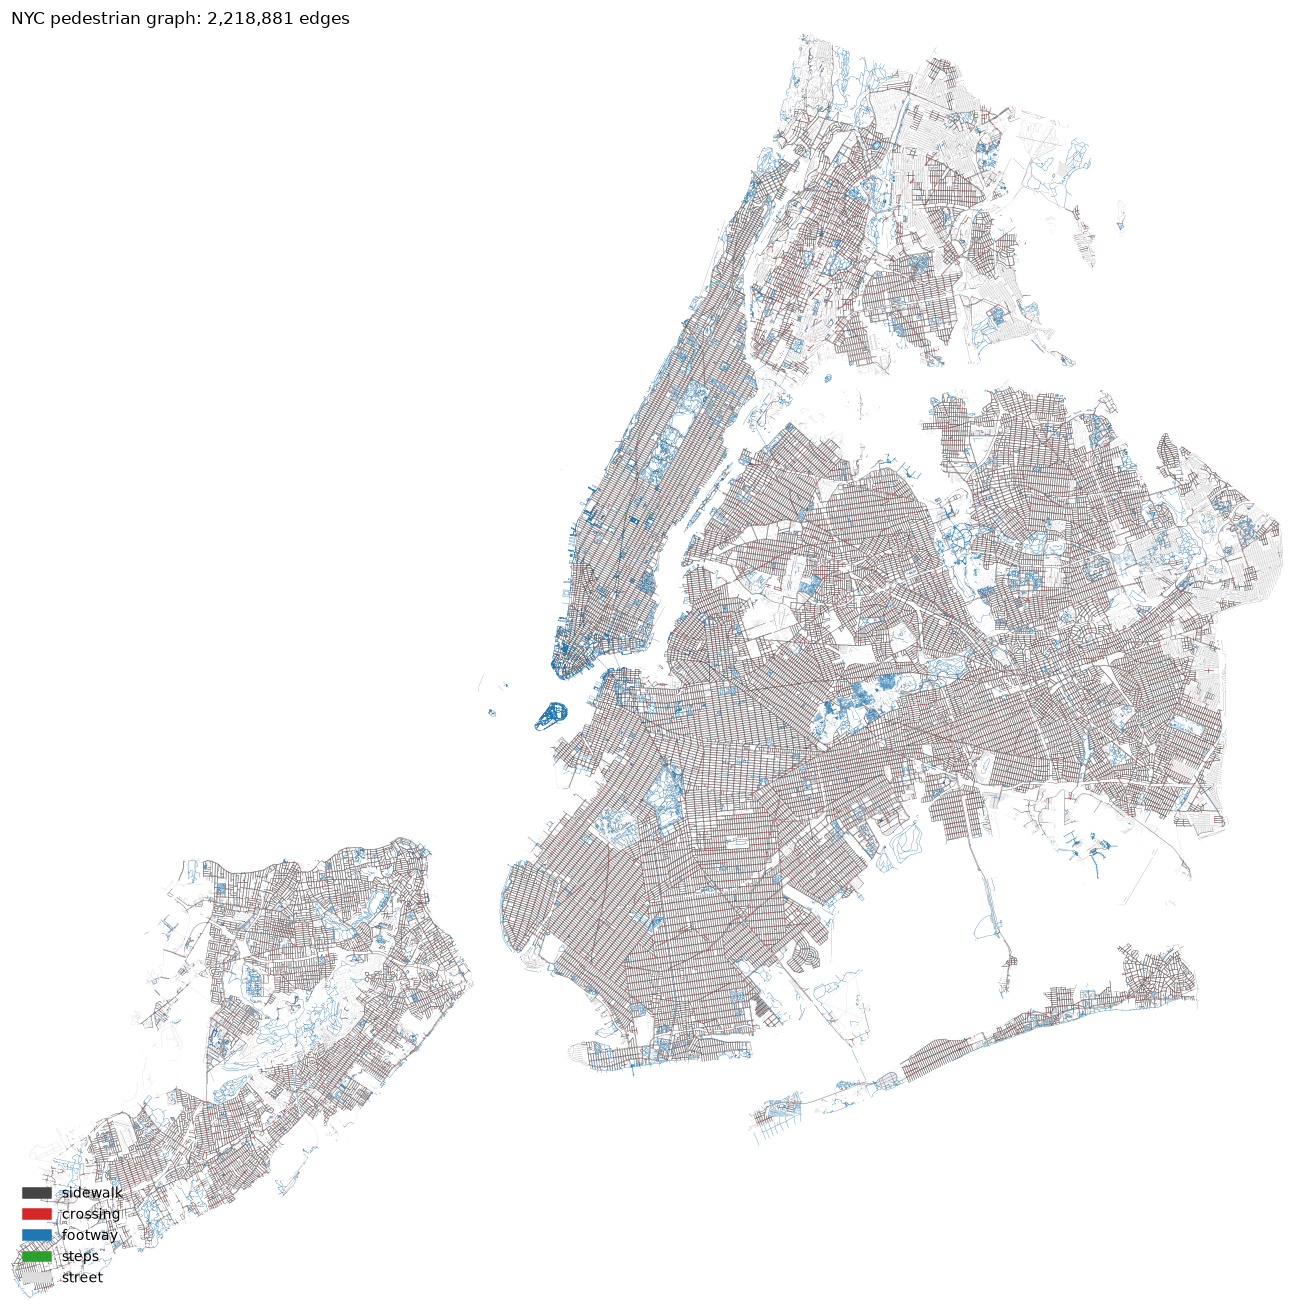

In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.collections import LineCollection
import shapely
from pyogrio import read_dataframe

edges = read_dataframe(OUT / "osw-split" / "nyc.edges.geojson", columns=["highway", "footway"])

geoms = edges.geometry.array
p0 = shapely.get_coordinates(shapely.get_point(geoms, 0))
p1 = shapely.get_coordinates(shapely.get_point(geoms, -1))
segs = np.stack([p0, p1], axis=1)

footway = edges["footway"].fillna("")
highway = edges["highway"].fillna("")
cls = np.where(footway == "sidewalk", 0,
      np.where(footway == "crossing", 1,
      np.where(highway == "steps", 3,
      np.where(highway.isin(["footway", "pedestrian", "path"]), 2, 4))))

CLASS_NAMES  = ["sidewalk", "crossing", "footway", "steps", "street"]
CLASS_COLORS = ["#444444", "#d62728", "#1f77b4", "#2ca02c", "#dddddd"]
colors = np.take(CLASS_COLORS, cls)

order = np.argsort(cls == 4)[::-1]   # draw streets first, pedestrian classes on top

fig, ax = plt.subplots(figsize=(12, 12), dpi=110)
lc = LineCollection(segs[order], colors=colors[order], linewidths=0.15,
                    alpha=0.7, antialiased=True, rasterized=True)
ax.add_collection(lc)

ax.set_xlim(segs[:, :, 0].min(), segs[:, :, 0].max())
ax.set_ylim(segs[:, :, 1].min(), segs[:, :, 1].max())
ax.set_aspect(1 / np.cos(np.radians(40.71)))   # equirectangular correction at NYC latitude
ax.set_xticks([]); ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

legend = [mpatches.Patch(color=c, label=n) for c, n in zip(CLASS_COLORS, CLASS_NAMES)]
ax.legend(handles=legend, loc="lower left", frameon=False, fontsize=9)
ax.set_title(f"NYC pedestrian graph: {len(edges):,} edges", fontsize=11, loc="left")
plt.tight_layout()
plt.show()